In [1]:
import pandas as pd

df = pd.read_csv("heart.csv.csv")

print(df.head(10))
print("\nShape:", df.shape)
print("\nDataset Information:")
print(df.info())

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   
5   39   M           NAP        120          339          0     Normal    170   
6   45   F           ATA        130          237          0     Normal    170   
7   54   M           ATA        110          208          0     Normal    142   
8   37   M           ASY        140          207          0     Normal    130   
9   48   F           ATA        120          284          0     Normal    120   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1     

In [2]:
print(df.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [3]:
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

df = df.drop_duplicates()

print("New Shape:", df.shape)

Duplicate Rows: 0
New Shape: (918, 12)


In [4]:
chol_zero = (df["Cholesterol"] == 0).sum()
bp_zero = (df["RestingBP"] == 0).sum()

print("Cholesterol = 0:", chol_zero)
print("RestingBP = 0:", bp_zero)

Cholesterol = 0: 172
RestingBP = 0: 1


In [5]:
print("Before Cleaning")
print(df[["Cholesterol","RestingBP"]].describe())

df["Cholesterol"] = df["Cholesterol"].astype(float)
df["RestingBP"] = df["RestingBP"].astype(float)
chol_mean = df.loc[df["Cholesterol"] != 0, "Cholesterol"].mean()
bp_mean = df.loc[df["RestingBP"] != 0, "RestingBP"].mean()


df.loc[df["Cholesterol"] == 0, "Cholesterol"] = chol_mean
df.loc[df["RestingBP"] == 0, "RestingBP"] = bp_mean


df["Cholesterol"] = df["Cholesterol"].round(2)
df["RestingBP"] = df["RestingBP"].round(2)

print("After Cleaning")
print(df[["Cholesterol","RestingBP"]].describe())

Before Cleaning
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    198.799564  132.396514
std     109.384145   18.514154
min       0.000000    0.000000
25%     173.250000  120.000000
50%     223.000000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000
After Cleaning
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


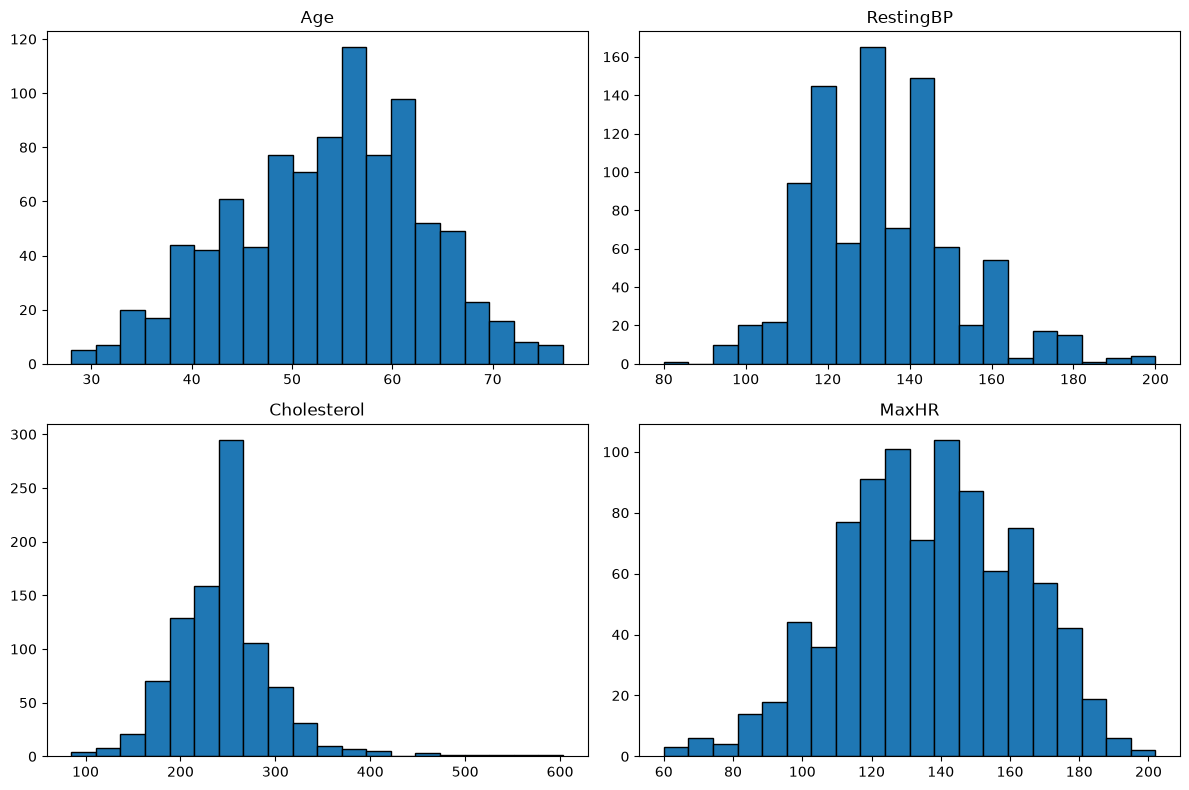

In [6]:
import matplotlib.pyplot as plt

def plot_histograms(data):
    cols = ["Age","RestingBP","Cholesterol","MaxHR"]

    plt.figure(figsize=(12,8))

    for i, col in enumerate(cols):
        plt.subplot(2,2,i+1)
        plt.hist(data[col], bins=20, edgecolor='black')
        plt.title(col)

    plt.tight_layout()
    plt.show()

plot_histograms(df)

In [7]:
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(exclude="number").columns.tolist()

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']
Categorical Columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [8]:
df_encoded = pd.get_dummies(df, columns=cat_cols)

print(df_encoded.shape)
print(df_encoded.head())

(918, 21)
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0  False   True              False  ...              False             False   
1   True  False              False  ...               True             False   
2  False   True              False  ...              False             False   
3   True  False               True  ...              False             False   
4  False   True              False  ...               True             False   

   RestingECG_LVH  RestingECG_Normal  RestingECG_ST  Exerc

In [9]:
print(df_encoded.shape)
print(df_encoded.columns.tolist())

(918, 21)
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


1. Invalid values found

Cholesterol = 0 → 172 rows
RestingBP = 0 → 1 row

These values were replaced with the mean of the respective columns (excluding zero values).

2. Why handle invalid values?

A cholesterol value of 0 mg/dL and blood pressure of 0 mmHg are medically impossible.
Keeping such values would reduce model accuracy and produce misleading analysis.

3. Purpose of One-Hot Encoding

Machine learning algorithms require numerical input.
One-Hot Encoding converts categorical variables into binary (0/1) columns without introducing false ordering.

4. Other observations

No missing values were present.
No duplicate rows were found.
After cleaning, the dataset became more realistic.
Final encoded dataset contains 918 rows and 21 columns.